# 2.1) Pendulum-v1

This contains the trainings and analyses for question 2.1.

## 1. Reward Function Definition -
The reward function is a combination of multiple terms -
- angle term : this penalizes the difference between the current angle and target angle.
- velocity term : this penalizes the angular velocity of the pendulum. It is given a smaller weight.
- torque term : this makes sure that the actions are not too large, which would result in jerky motion which is undesirable.
- cosine angle term : also added a cosine of the error between angle and target angle for the range of -90 < error < 90. This reward term increases as the angle comes close to the target angle.
- the cosine term is given a larger weight since its values are much smaller than the other terms like angle error.

In [ ]:
import numpy as np

def _reward(self, theta, theta_dot, action):
        angle_error = self._angle_normalize(theta - self.target_theta)
        torque = np.clip(action, self.action_space.low, self.action_space.high)

        base_reward = -(angle_error ** 2 + 0.01 * (theta_dot ** 2) + 0.001 * np.sum(torque ** 2))
        cos_bonus = 0.0
        if abs(angle_error) <= (np.pi / 2):
            cos_bonus = self.cosine_weight * np.cos(angle_error)

        return base_reward + float(cos_bonus)

## 2. Python code and training for target theta values of [0, -10, 30, -60, 90, -90, 120, -150]
The pytorch_sac implementation is modified to include the modified Pendulum-v1 environment as required by 2.1. Initial experiments suggest that the training reward settles and reaches optimal performance after around 30-40k timesteps. Hence we run each training for 35k steps.

The `pytorch_sac/train.py` file was modified to run trainings for 55k timesteps for all the seeds and target theta values. Below is the analysis of the training.

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [52, 8, 42, 32, 31, 10, 0, 11, 15, 21, 44, 63, 90]
THETAS = [-10, -60, -90, -150, 0, 30, 90, 120]


def load_runs(theta, split):
    runs = []
    
    for seed in SEEDS:
        path = f"exp/theta_sweep/theta_{theta}/seed_{seed}/{split}.csv"
        if not os.path.exists(path):
            print(f"Warning: Missing {path}")
            continue
        
        df = pd.read_csv(path)
        
        reward = df.iloc[:, -2].to_numpy()
        step = df.iloc[:, -1].to_numpy()
        
        runs.append(pd.DataFrame({
            "step": step,
            "reward": reward
        }))
    
    return runs


def aggregate_runs(runs):
    merged = None
    
    for i, run in enumerate(runs):
        run = run.rename(columns={"reward": f"reward_{i}"})
        if merged is None:
            merged = run
        else:
            merged = pd.merge(merged, run, on="step", how="outer")
    
    merged = merged.sort_values("step")
    
    reward_cols = [c for c in merged.columns if c.startswith("reward_")]
    rewards = merged[reward_cols].to_numpy(dtype=float)
    
    mean = np.nanmean(rewards, axis=1)
    std = np.nanstd(rewards, axis=1)
    n = np.sum(~np.isnan(rewards), axis=1)
    
    ci95 = 1.96 * std / np.sqrt(n)
    
    return merged["step"].to_numpy(), mean, ci95


def plot_all_thetas(split):
    plt.figure(figsize=(10, 6))
    
    for theta in THETAS:
        runs = load_runs(theta, split)
        
        if len(runs) == 0:
            continue
        
        step, mean, ci = aggregate_runs(runs)
        
        plt.plot(step, mean, label=f"θ={theta}")
        plt.fill_between(step, mean - ci, mean + ci, alpha=0.2)
    
    plt.xlabel("Step")
    plt.ylabel("Episode Reward")
    plt.title(f"{split.capitalize()} Reward (Mean ± 95% CI over seeds)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_all():
    plot_all_thetas("train")
    plot_all_thetas("eval")

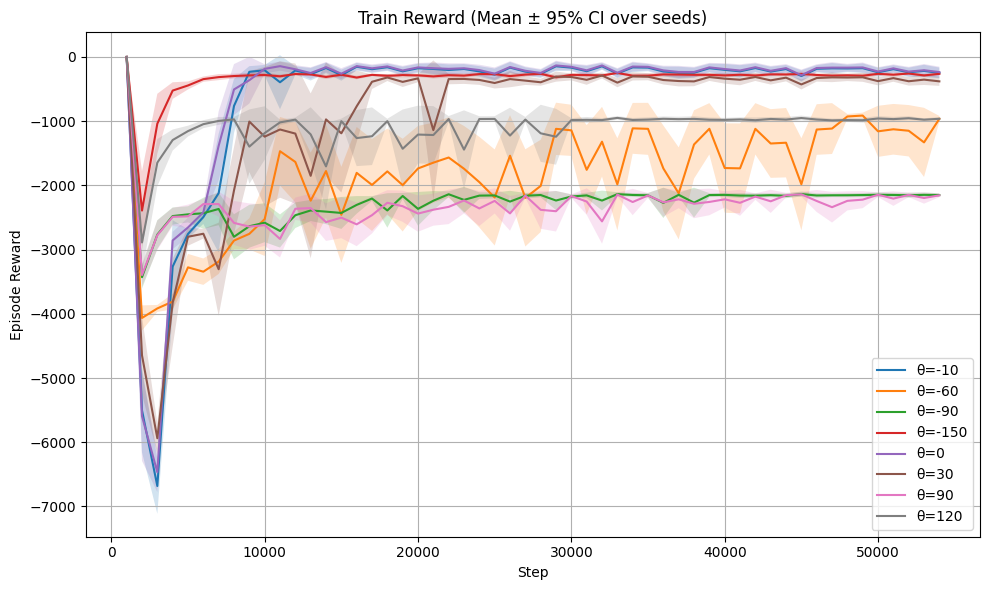

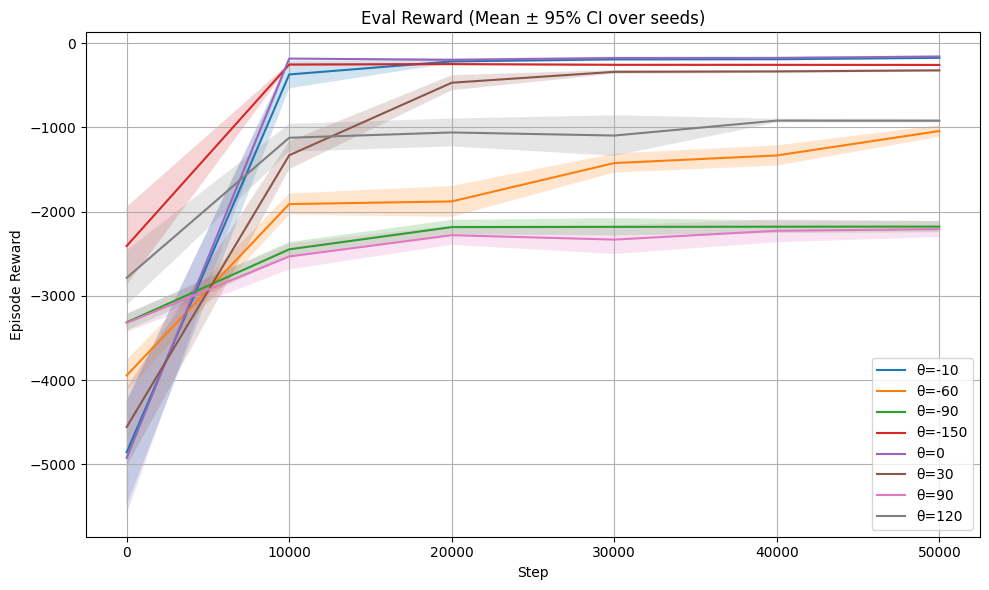

In [52]:
plot_all()

In [53]:
def print_final_rewards(mode="last_k_mean", last_k=10):
    """
    Print final rewards for all thetas across train and eval splits.
    
    Args:
        mode: "final" (last value) or "last_k_mean" (mean of last k values)
        last_k: number of final steps to average over (for last_k_mean mode)
    """
    import pandas as pd
    
    print(f"\n{'='*80}")
    print(f"Final Rewards Summary ({mode})")
    print(f"{'='*80}\n")
    
    # Create results dataframe
    results = []
    
    for theta in THETAS:
        train_runs = load_runs(theta, "train")
        eval_runs = load_runs(theta, "eval")
        
        # Get final rewards for train
        train_values = []
        for run in train_runs:
            rewards = run["reward"].to_numpy()
            if len(rewards) > 0:
                if mode == "final":
                    train_values.append(rewards[-1])
                elif mode == "last_k_mean":
                    train_values.append(np.mean(rewards[-last_k:]))
        
        # Get final rewards for eval
        eval_values = []
        for run in eval_runs:
            rewards = run["reward"].to_numpy()
            if len(rewards) > 0:
                if mode == "final":
                    eval_values.append(rewards[-1])
                elif mode == "last_k_mean":
                    eval_values.append(np.mean(rewards[-last_k:]))
        
        # Compute statistics
        train_mean = np.mean(train_values) if train_values else np.nan
        train_std = np.std(train_values) if len(train_values) > 1 else np.nan
        eval_mean = np.mean(eval_values) if eval_values else np.nan
        eval_std = np.std(eval_values) if len(eval_values) > 1 else np.nan
        
        results.append({
            'Theta (°)': theta,
            'Train Mean': train_mean,
            'Train Std': train_std,
            'Eval Mean': eval_mean,
            'Eval Std': eval_std
        })
    
    df_results = pd.DataFrame(results)
    print(df_results.to_string(index=False))
    print(f"\n{'='*80}\n")
    
    return df_results

# Print final rewards
print_final_rewards(mode="last_k_mean", last_k=1)


Final Rewards Summary (last_k_mean)

 Theta (°)   Train Mean  Train Std    Eval Mean   Eval Std
       -10  -248.949251 153.128588  -174.377531  27.826977
       -60  -963.344522  82.926941 -1042.909647 127.338061
       -90 -2150.853967  53.444218 -2177.404900 123.831062
      -150  -263.225281  38.717561  -259.036490  25.759390
         0  -235.674621 155.298709  -159.409641  28.205246
        30  -380.025859 129.361590  -323.186739  30.525138
        90 -2154.619404  54.560289 -2207.448709 172.926233
       120  -962.970084  52.424917  -920.596609  39.610293




,Theta (°),Train Mean,Train Std,Eval Mean,Eval Std
0,-10,-248.949251,153.128588,-174.377531,27.826977
1,-60,-963.344522,82.926941,-1042.909647,127.338061
2,-90,-2150.853967,53.444218,-2177.404900,123.831062
3,-150,-263.225281,38.717561,-259.036490,25.759390
4,0,-235.674621,155.298709,-159.409641,28.205246
5,30,-380.025859,129.361590,-323.186739,30.525138
6,90,-2154.619404,54.560289,-2207.448709,172.926233
7,120,-962.970084,52.424917,-920.596609,39.610293


## 3. Manual Alpha Tuning - Sensitivity Analysis
Comparing performance across different fixed alpha values for the four target angles: [-60, 90, 120, -150]


In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [52, 8, 42, 32, 31, 10, 11, 15, 21, 44, 63, 90]
ALPHAS = [0.1, 0.01, 0.2, 0.3, 0.03, 0.05]


def get_scalar_from_run(df, mode="final", last_k=10):
    rewards = df.iloc[:, -2].to_numpy()
    
    if len(rewards) == 0:
        return np.nan
    
    if mode == "final":
        return rewards[-1]
    elif mode == "last_k_mean":
        return np.mean(rewards[-last_k:])
    else:
        raise ValueError("Unknown mode")


def collect_alpha_data(theta, split, mode="final"):
    means = []
    cis = []
    
    for alpha in ALPHAS:
        seed_values = []
        
        for seed in SEEDS:
            path = f"exp/alpha_sweep/theta_{theta}/alpha_{alpha}/seed_{seed}/{split}.csv"
            
            if not os.path.exists(path):
                print(f"Missing: {path}")
                continue
            
            df = pd.read_csv(path)
            val = get_scalar_from_run(df, mode=mode)
            
            if not np.isnan(val):
                seed_values.append(val)
        
        if len(seed_values) == 0:
            means.append(np.nan)
            cis.append(np.nan)
            continue
        
        seed_values = np.array(seed_values)
        
        mean = np.mean(seed_values)
        std = np.std(seed_values)
        n = len(seed_values)
        
        ci95 = 1.96 * std / np.sqrt(n)
        
        means.append(mean)
        cis.append(ci95)
    
    return np.array(ALPHAS), np.array(means), np.array(cis)


def plot_alpha_sensitivity(theta, split, mode="final"):
    alphas, means, cis = collect_alpha_data(theta, split, mode)
    
    # Sort for proper left→right plotting
    order = np.argsort(alphas)
    alphas = alphas[order]
    means = means[order]
    cis = cis[order]
    
    plt.figure(figsize=(8, 5))
    
    plt.errorbar(
        alphas,
        means,
        yerr=cis,
        fmt='o-',           # marker + line
        capsize=4,
        linewidth=2,
        markersize=6
    )
    
    plt.xlabel("Temperature (α)")
    plt.ylabel("Episode Reward")
    plt.title(f"θ = {theta}° — alpha sensitivity ({split})")
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_theta_alpha_sensitivity(theta, mode="final"):
    plot_alpha_sensitivity(theta, "train", mode)
    plot_alpha_sensitivity(theta, "eval", mode)


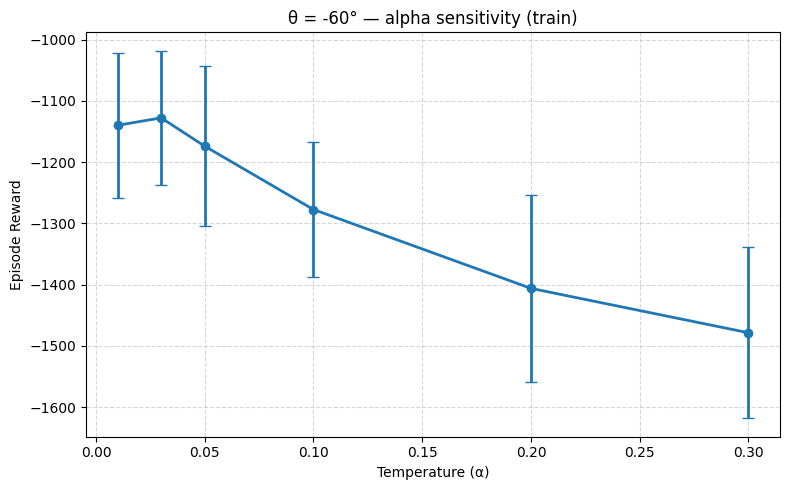

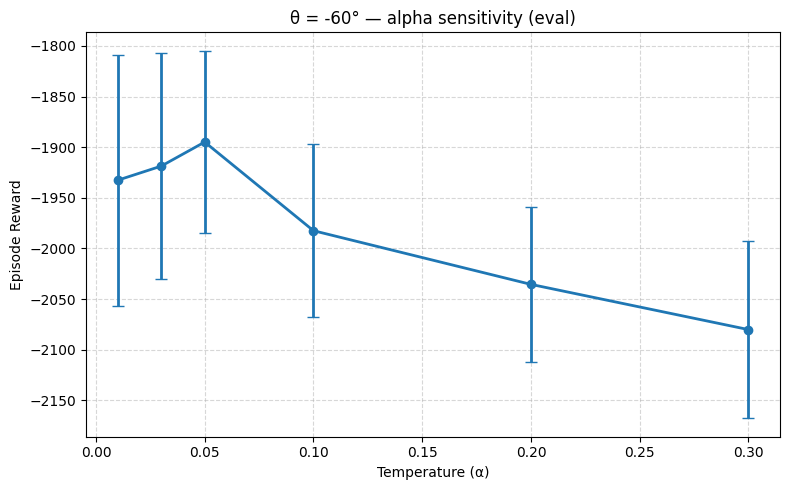

In [55]:
plot_theta_alpha_sensitivity(theta=-60, mode="last_k_mean")

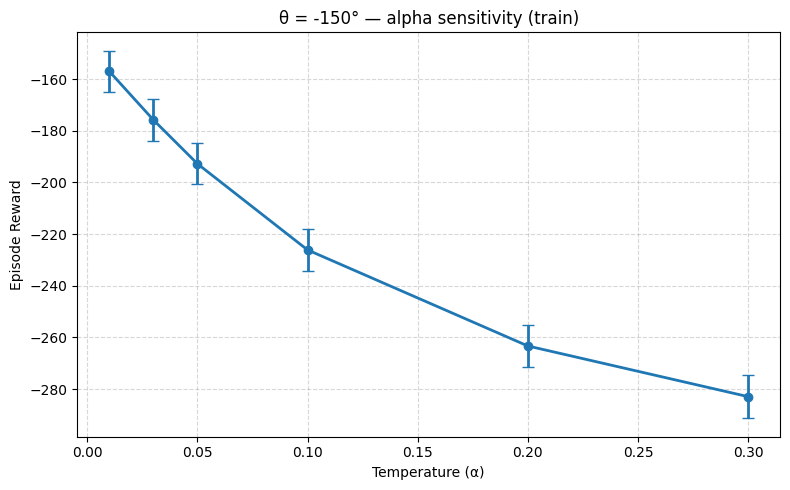

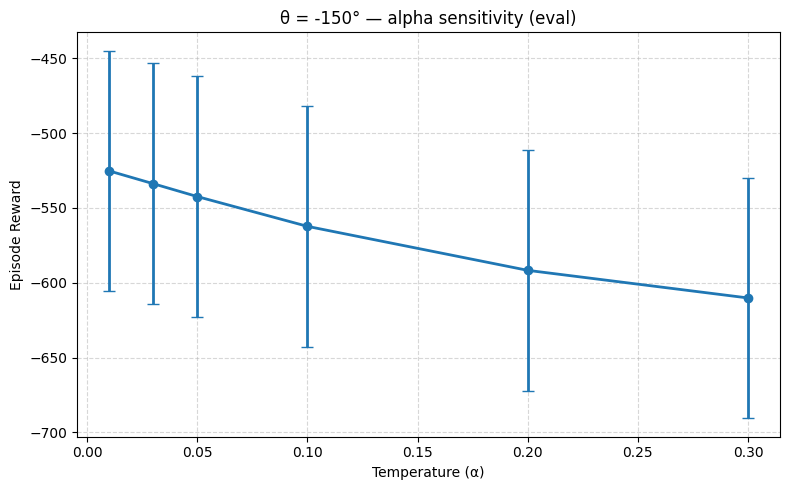

In [56]:
plot_theta_alpha_sensitivity(theta=-150, mode="last_k_mean")

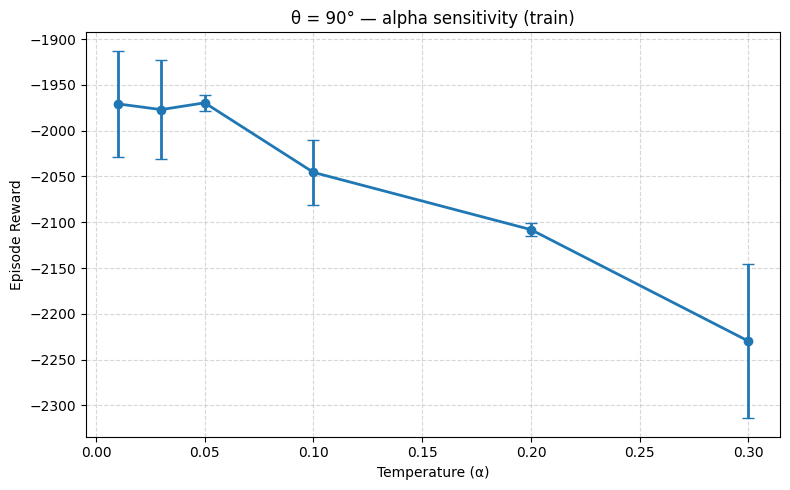

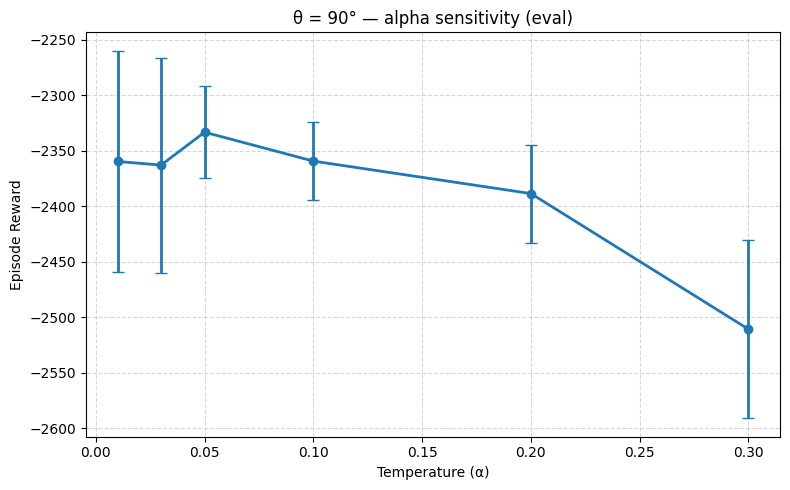

In [57]:
plot_theta_alpha_sensitivity(theta=90, mode="last_k_mean")

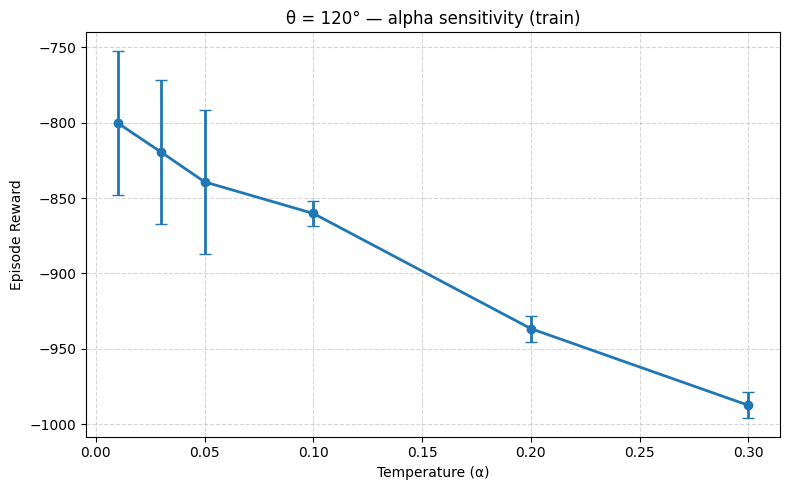

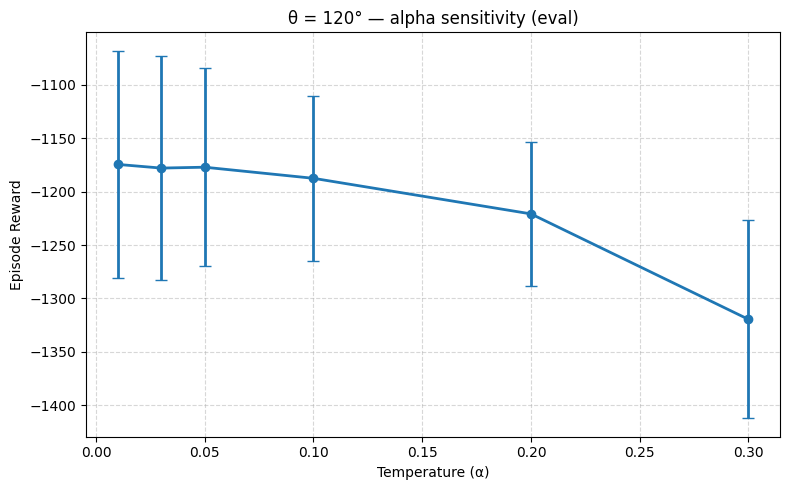

In [58]:
plot_theta_alpha_sensitivity(theta=120, mode="last_k_mean")

Optimal Alphas -
- 120 - 0.1
- 90 - 0.05
- -150 - 0.01
- -60 - 0.05

Now we compare performance of the optimal alpha and the automated tuning performance for the same theta by plotting eval episode_reward.

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [11, 15, 21, 44, 63, 90]


def load_runs_theta_sweep(theta):
    runs = []
    
    for seed in SEEDS:
        path = f"exp/theta_sweep/theta_{theta}/seed_{seed}/eval.csv"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        
        df = pd.read_csv(path)
        runs.append(pd.DataFrame({
            "step": df.iloc[:, -1],
            "reward": df.iloc[:, -2]
        }))
    
    return runs


def load_runs_alpha_sweep(theta, alpha):
    runs = []
    
    for seed in SEEDS:
        path = f"exp/alpha_sweep/theta_{theta}/alpha_{alpha}/seed_{seed}/eval.csv"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        
        df = pd.read_csv(path)
        runs.append(pd.DataFrame({
            "step": df.iloc[:, -1],
            "reward": df.iloc[:, -2]
        }))
    
    return runs


def aggregate_runs(runs):
    merged = None
    
    for i, run in enumerate(runs):
        run = run.rename(columns={"reward": f"r_{i}"})
        if merged is None:
            merged = run
        else:
            merged = pd.merge(merged, run, on="step", how="outer")
    
    merged = merged.sort_values("step")
    
    reward_cols = [c for c in merged.columns if c.startswith("r_")]
    rewards = merged[reward_cols].to_numpy(dtype=float)
    
    mean = np.nanmean(rewards, axis=1)
    std = np.nanstd(rewards, axis=1)
    n = np.sum(~np.isnan(rewards), axis=1)
    
    ci95 = 1.96 * std / np.sqrt(n)
    
    return merged["step"].to_numpy(), mean, ci95


def plot_comparison(theta, alpha):
    # Load both experiment groups
    runs_theta = load_runs_theta_sweep(theta)
    runs_alpha = load_runs_alpha_sweep(theta, alpha)
    
    if len(runs_theta) == 0 or len(runs_alpha) == 0:
        print("Missing data for comparison")
        return
    
    step_t, mean_t, ci_t = aggregate_runs(runs_theta)
    step_a, mean_a, ci_a = aggregate_runs(runs_alpha)
    
    plt.figure(figsize=(9, 5))
    
    # Theta sweep baseline
    plt.plot(step_t, mean_t, label=f"Auto (θ={theta})", linewidth=2)
    plt.fill_between(step_t, mean_t - ci_t, mean_t + ci_t, alpha=0.2)
    
    # Alpha sweep variant
    plt.plot(step_a, mean_a, label=f"Fixed Alpha (θ={theta}, α={alpha})", linewidth=2)
    plt.fill_between(step_a, mean_a - ci_a, mean_a + ci_a, alpha=0.2)
    
    plt.xlabel("Step")
    plt.ylabel("Episode Reward")
    plt.title(f"Eval Comparison: θ={theta}, α={alpha}")
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

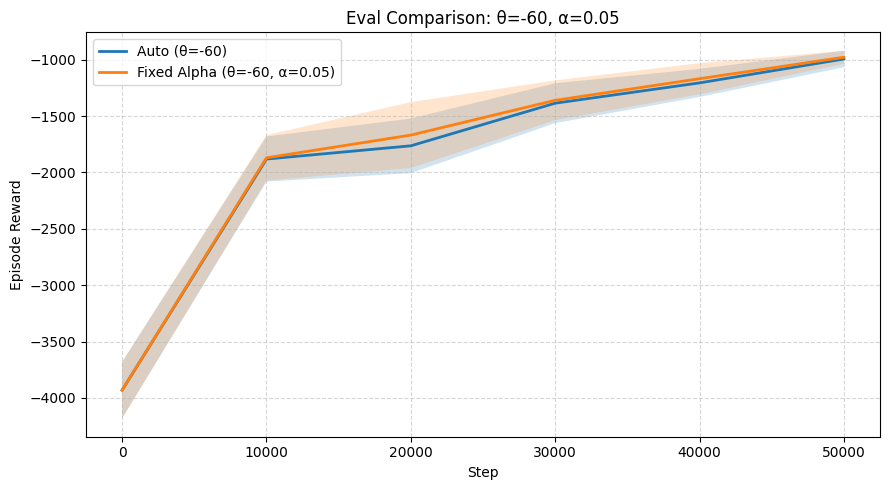

In [39]:
plot_comparison(theta=-60, alpha=0.05)

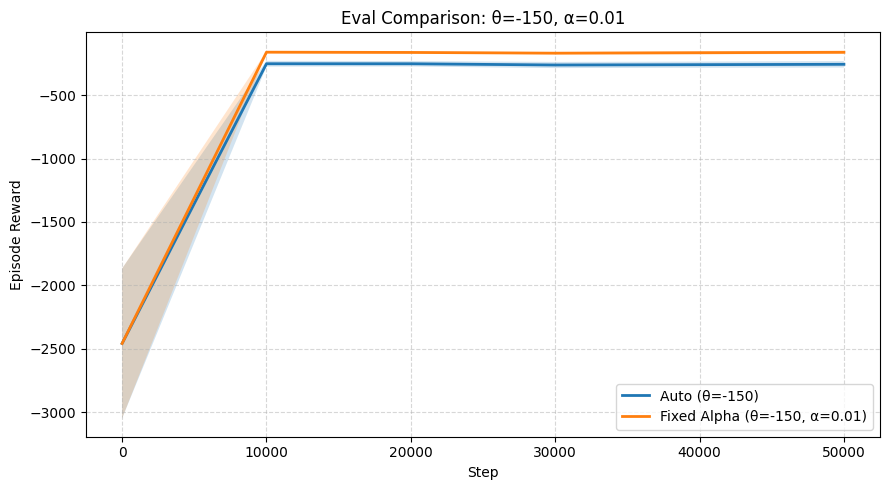

In [40]:
plot_comparison(theta=-150, alpha=0.01)

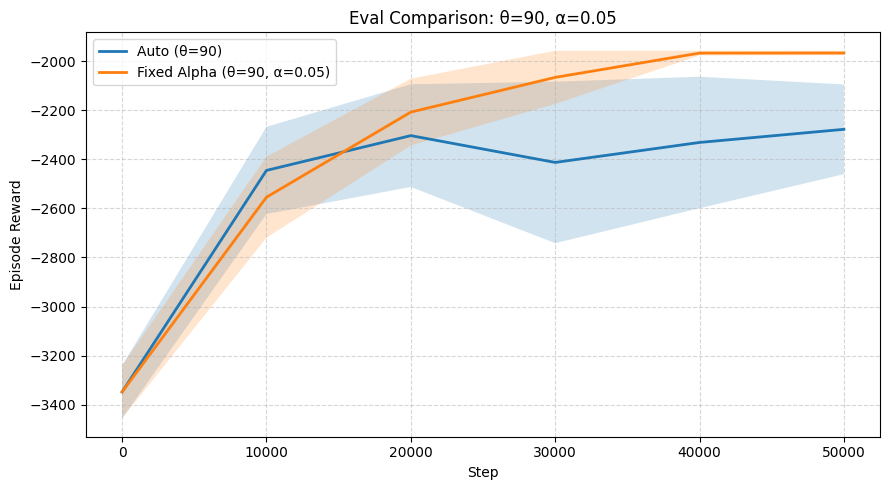

In [42]:
plot_comparison(theta=90, alpha=0.05)

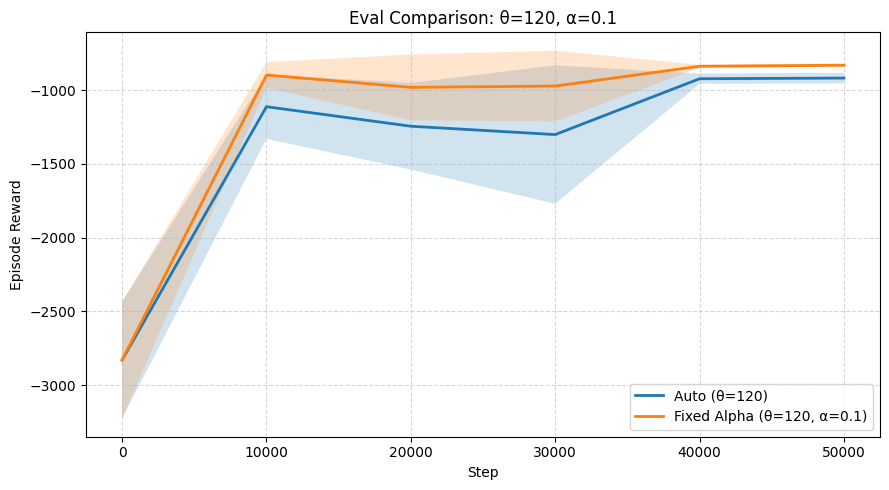

In [43]:
plot_comparison(theta=120, alpha=0.1)

# 4) Changing reward scales -
For theta=90, for both the fixed alpha 0.05 and automated tuning of alpha, we change the reward scale to 10 and 0.1 and compare performance.

Auto alpha scale sensitivity summary


,scale,n,mean,ci95
0,0.1,13,-2391.451594,66.687080
1,1.0,13,-2500.221723,77.230033
2,10.0,13,-2346.869261,45.214719



Fixed alpha (0.05) scale sensitivity summary


,scale,n,mean,ci95
0,0.1,13,-2496.045376,30.480485
1,1.0,13,-2354.609572,55.463390
2,10.0,13,-2343.467754,49.224414


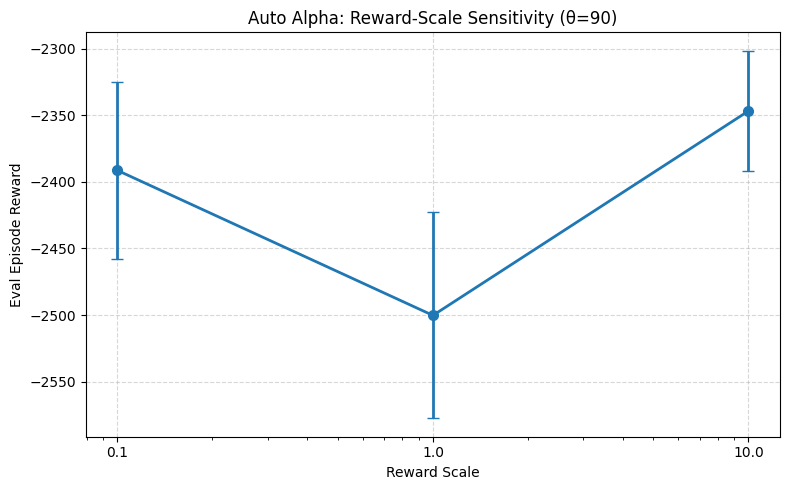

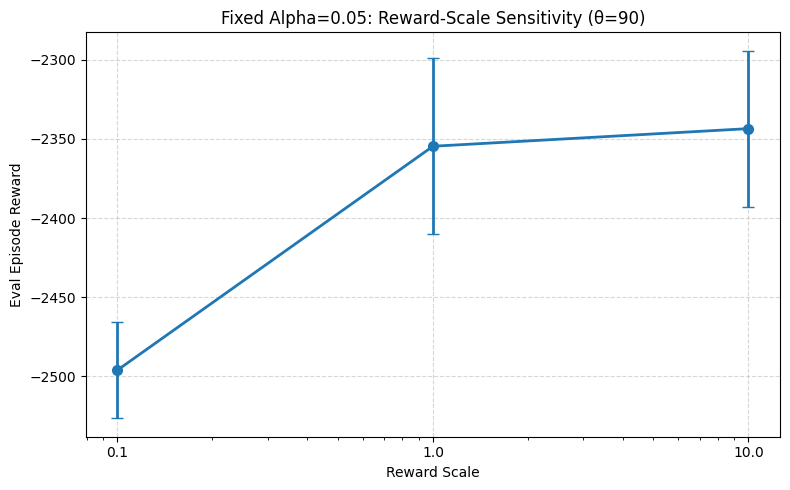

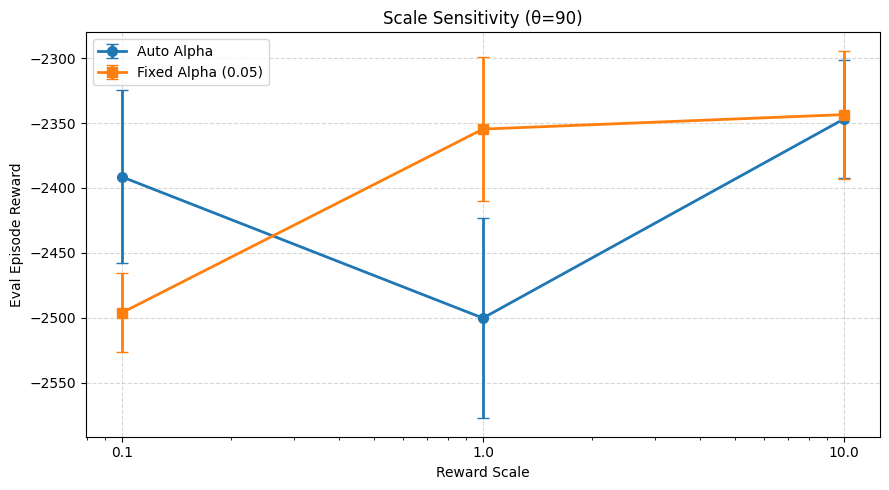

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

THETA_SCALE = 90
SCALES = [0.1, 1.0, 10.0]
SEEDS_SCALE = [44, 63, 11, 15, 90, 21, 52, 8, 42, 32, 31, 10, 98]


def _extract_reward_series(csv_path):
    """Return reward series from eval/train csv written by Logger."""
    df = pd.read_csv(csv_path)
    return df.iloc[:, -2].to_numpy(dtype=float)


def _scalar_from_csv(csv_path, mode="last_k_mean", last_k=10, scale_factor=1.0):
    rewards = _extract_reward_series(csv_path)
    if scale_factor is None or float(scale_factor) == 0.0:
        scale_factor = 1.0
    rewards = rewards / float(scale_factor)
    if rewards.size == 0:
        return np.nan
    if mode == "final":
        return float(rewards[-1])
    if mode == "last_k_mean":
        k = min(last_k, rewards.size)
        return float(np.mean(rewards[-k:]))
    raise ValueError("mode must be 'final' or 'last_k_mean'")


def _find_eval_csv(alpha_type, scale, seed, theta=THETA_SCALE):
    """
    Locate eval.csv for a given method/scale/seed.

    New logs:
      exp/scale_sweep/<alpha_type>/scale_<scale>/seed_<seed>/eval.csv

    Baseline scale=1.0 fallback (corresponding original logs):
      auto        -> exp/theta_sweep/theta_<theta>/seed_<seed>/eval.csv
      fixed_alpha -> exp/alpha_sweep/theta_<theta>/alpha_0.05/seed_<seed>/eval.csv
    """
    primary = f"exp/scale_sweep/{alpha_type}/scale_{scale}/seed_{seed}/eval.csv"
    if os.path.exists(primary):
        return primary

    # baseline fallback for original scale
    if float(scale) == 1.0:
        if alpha_type == "auto":
            fallback = f"exp/theta_sweep/theta_{theta}/seed_{seed}/eval.csv"
        elif alpha_type == "fixed_alpha":
            fallback = f"exp/alpha_sweep/theta_{theta}/alpha_0.05/seed_{seed}/eval.csv"
        else:
            fallback = None
        if fallback and os.path.exists(fallback):
            return fallback

    return None


def collect_scale_sensitivity(alpha_type, scales=SCALES, seeds=SEEDS_SCALE, mode="last_k_mean", last_k=10):
    rows = []
    for scale in scales:
        vals = []
        used_paths = []
        for seed in seeds:
            csv_path = _find_eval_csv(alpha_type=alpha_type, scale=scale, seed=seed, theta=THETA_SCALE)
            if csv_path is None:
                continue
            v = _scalar_from_csv(csv_path, mode=mode, last_k=last_k, scale_factor=scale)
            if not np.isnan(v):
                vals.append(v)
                used_paths.append(csv_path)

        vals = np.array(vals, dtype=float)
        n = int(vals.size)
        if n == 0:
            mean = np.nan
            ci95 = np.nan
        else:
            mean = float(np.mean(vals))
            std = float(np.std(vals))
            ci95 = float(1.96 * std / np.sqrt(n))

        rows.append({
            "alpha_type": alpha_type,
            "scale": float(scale),
            "n": n,
            "mean": mean,
            "ci95": ci95,
        })

    out = pd.DataFrame(rows).sort_values("scale").reset_index(drop=True)
    return out


def plot_scale_sensitivity(df, title):
    x = df["scale"].to_numpy(dtype=float)
    y = df["mean"].to_numpy(dtype=float)
    ci = df["ci95"].to_numpy(dtype=float)

    plt.figure(figsize=(8, 5))
    plt.errorbar(x, y, yerr=ci, fmt='o-', capsize=4, linewidth=2, markersize=7)
    plt.xscale("log")
    plt.xticks(x, [str(s) for s in x])
    plt.xlabel("Reward Scale")
    plt.ylabel("Eval Episode Reward")
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_scale_sensitivity_overlay(df_auto, df_fixed):
    plt.figure(figsize=(9, 5))

    x_a = df_auto["scale"].to_numpy(dtype=float)
    y_a = df_auto["mean"].to_numpy(dtype=float)
    c_a = df_auto["ci95"].to_numpy(dtype=float)

    x_f = df_fixed["scale"].to_numpy(dtype=float)
    y_f = df_fixed["mean"].to_numpy(dtype=float)
    c_f = df_fixed["ci95"].to_numpy(dtype=float)

    plt.errorbar(x_a, y_a, yerr=c_a, fmt='o-', capsize=4, linewidth=2, markersize=7, label="Auto Alpha")
    plt.errorbar(x_f, y_f, yerr=c_f, fmt='s-', capsize=4, linewidth=2, markersize=7, label="Fixed Alpha (0.05)")

    plt.xscale("log")
    merged_x = sorted(set(list(x_a) + list(x_f)))
    plt.xticks(merged_x, [str(s) for s in merged_x])
    plt.xlabel("Reward Scale")
    plt.ylabel("Eval Episode Reward")
    plt.title(f"Scale Sensitivity (θ={THETA_SCALE})")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# Build summaries for both methods (includes scale=1.0 via direct logs or fallback logs)
df_auto = collect_scale_sensitivity(alpha_type="auto", mode="last_k_mean", last_k=10)
df_fixed = collect_scale_sensitivity(alpha_type="fixed_alpha", mode="last_k_mean", last_k=10)

print("Auto alpha scale sensitivity summary")
display(df_auto[["scale", "n", "mean", "ci95"]])
print("\nFixed alpha (0.05) scale sensitivity summary")
display(df_fixed[["scale", "n", "mean", "ci95"]])

# Per-method plots (similar sensitivity style)
plot_scale_sensitivity(df_auto, title=f"Auto Alpha: Reward-Scale Sensitivity (θ={THETA_SCALE})")
plot_scale_sensitivity(df_fixed, title=f"Fixed Alpha=0.05: Reward-Scale Sensitivity (θ={THETA_SCALE})")

# Combined comparison
plot_scale_sensitivity_overlay(df_auto, df_fixed)

# PEBBLE

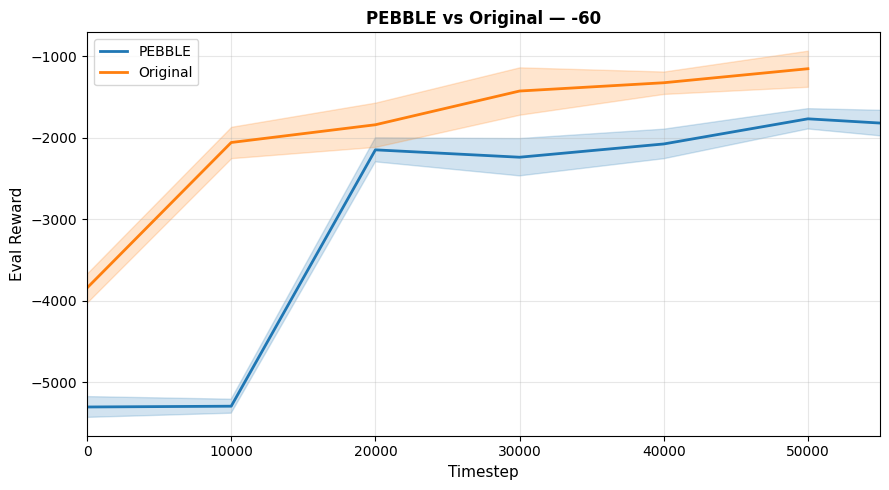

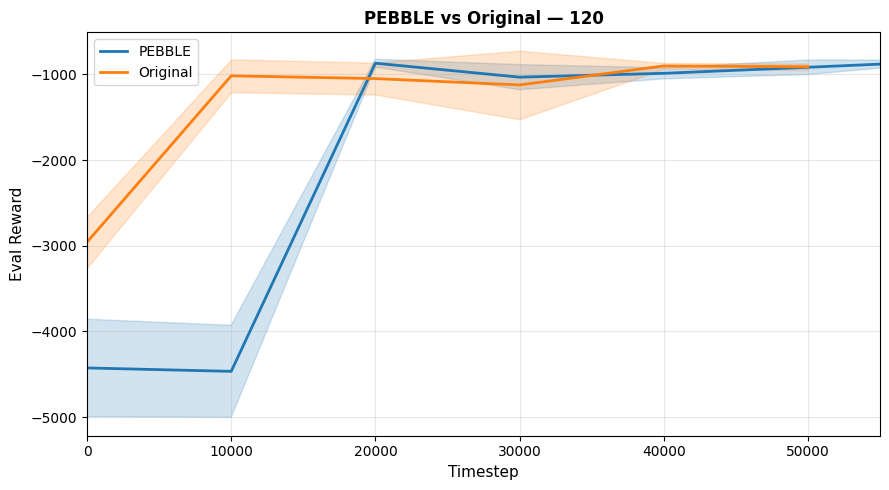

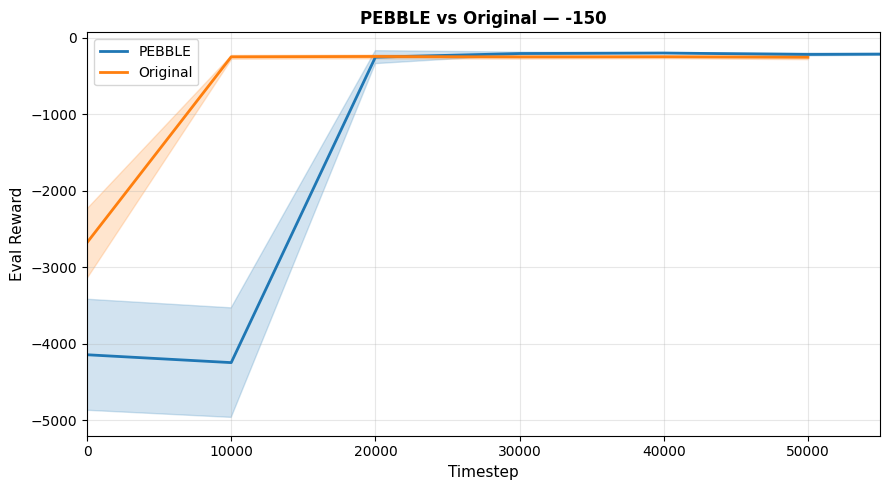

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TEST_GROUP_ROOT = "exp/test_group"
THETA_SWEEP_ROOT = "exp/theta_sweep"
SEEDS_TEST = [10, 11, 42, 44, 52, 90, 98]

def _load_eval_csv(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    return pd.DataFrame({"step": df.iloc[:, -1], "reward": df.iloc[:, -2]})

def load_test_group_runs(test_root=TEST_GROUP_ROOT, seeds=SEEDS_TEST):
    runs_by_theta = {}
    if not os.path.exists(test_root):
        return runs_by_theta
    for theta_dir in sorted(os.listdir(test_root)):
        theta_path = os.path.join(test_root, theta_dir)
        if not os.path.isdir(theta_path) or not theta_dir.startswith("theta_"):
            continue
        theta_val = theta_dir.split("theta_")[-1]  # radians string
        try:
            theta_rad = float(theta_val)
        except Exception:
            continue
        runs = []
        for seed in seeds:
            seed_dir = f"seed_{seed}"
            csv_path = os.path.join(theta_path, seed_dir, "eval.csv")
            r = _load_eval_csv(csv_path)
            if r is not None:
                runs.append(r)
        if runs:
            runs_by_theta[theta_rad] = runs
    return runs_by_theta

def load_theta_sweep_runs_for_seeds(theta_deg, seeds=SEEDS_TEST, root=THETA_SWEEP_ROOT):
    path = os.path.join(root, f"theta_{theta_deg}")
    runs = []
    if not os.path.exists(path):
        return runs
    for seed in seeds:
        csv_path = os.path.join(path, f"seed_{seed}", "eval.csv")
        r = _load_eval_csv(csv_path)
        if r is not None:
            runs.append(r)
    return runs

def aggregate_eval_runs(runs):
    if len(runs) == 0:
        return np.array([]), np.array([]), np.array([])
    merged = None
    for i, run in enumerate(runs):
        run = run.rename(columns={"reward": f"r_{i}"})
        if merged is None:
            merged = run
        else:
            merged = pd.merge(merged, run, on="step", how="outer")
    merged = merged.sort_values("step")
    reward_cols = [c for c in merged.columns if c.startswith("r_")]
    rewards = merged[reward_cols].to_numpy(dtype=float)
    mean = np.nanmean(rewards, axis=1)
    std = np.nanstd(rewards, axis=1)
    n = np.sum(~np.isnan(rewards), axis=1)
    ci95 = 1.96 * std / np.sqrt(np.maximum(n, 1))
    return merged["step"].to_numpy(), mean, ci95

# Load test_group runs (theta in radians) and compare to theta_sweep (degrees)
test_runs = load_test_group_runs()
if len(test_runs) == 0:
    print("No test_group runs found under exp/test_group")

# Only plot these target degrees (user-requested)
TARGET_DEGREES = [-60, 120, -150]
for target_deg in TARGET_DEGREES:
    target_rad = float(target_deg) * np.pi / 180.0
    if len(test_runs) == 0:
        continue
    # find nearest available theta in test_runs (keys are radians)
    nearest_rad = min(test_runs.keys(), key=lambda k: abs(k - target_rad))
    runs_test = test_runs[nearest_rad]
    step_tg, mean_tg, ci_tg = aggregate_eval_runs(runs_test)
    # find matching theta_sweep folder using integer degrees
    theta_deg_int = int(round(nearest_rad * 180.0 / np.pi))
    runs_sweep = load_theta_sweep_runs_for_seeds(theta_deg_int)
    if len(runs_sweep) > 0:
        step_s, mean_s, ci_s = aggregate_eval_runs(runs_sweep)
    else:
        step_s, mean_s, ci_s = (np.array([]), np.array([]), np.array([]))
    plt.figure(figsize=(9, 5))
    if step_tg.size > 0:
        plt.plot(step_tg, mean_tg, label=f"PEBBLE", linewidth=2, color="#1f77b4")
        plt.fill_between(step_tg, mean_tg - ci_tg, mean_tg + ci_tg, alpha=0.2, color="#1f77b4")
    if step_s.size > 0:
        # label original in radians as requested
        orig_rad = float(theta_deg_int) * np.pi / 180.0
        plt.plot(step_s, mean_s, label=f"Original", linewidth=2, color="#ff7f0e")
        plt.fill_between(step_s, mean_s - ci_s, mean_s + ci_s, alpha=0.2, color="#ff7f0e")
    plt.xlabel("Timestep", fontsize=11)
    plt.ylabel("Eval Reward", fontsize=11)
    plt.title(f"PEBBLE vs Original — {theta_deg_int}", fontsize=12, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 55000)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# Varying Feedback Budget

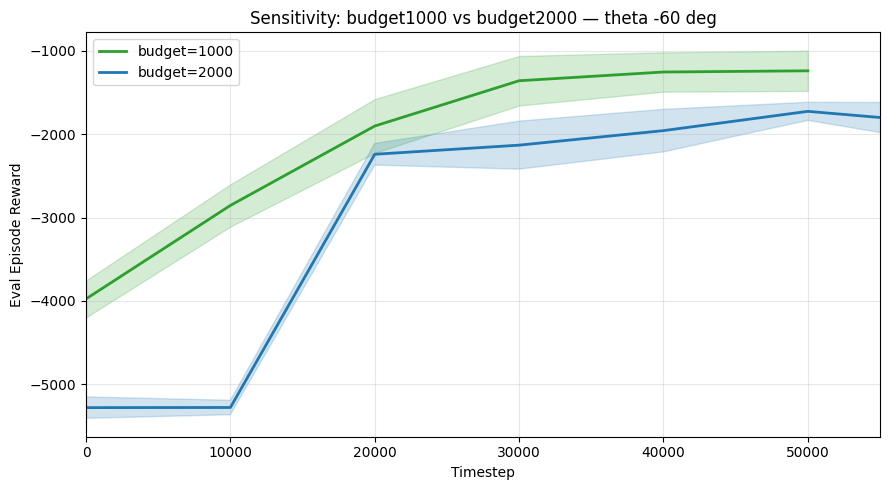

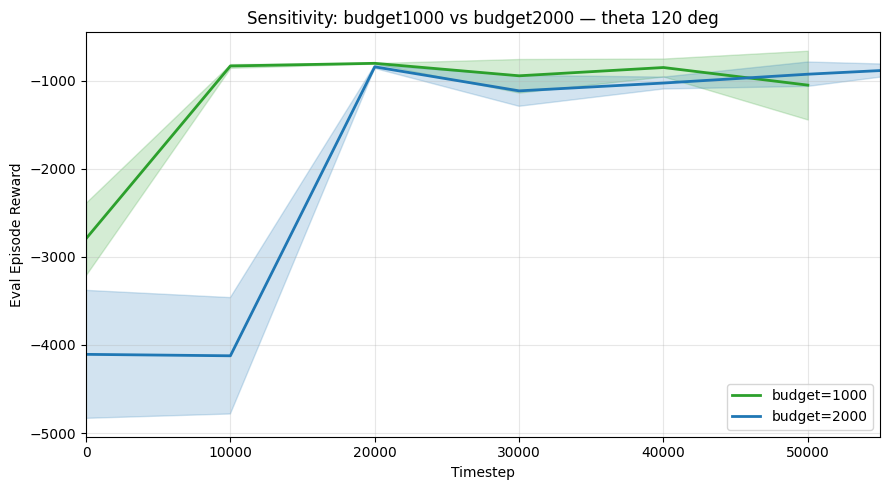

In [16]:
PEBBLE1000_ROOT = "exp/pebble/budget_1000"
TEST_ROOT = "exp/test_group"
SEEDS = [10, 44, 52, 90]
TARGET_DEGS = [-60, 120]

def _load_eval_csv(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    return pd.DataFrame({"step": df.iloc[:, -1], "reward": df.iloc[:, -2]})

def find_nearest_test_dir_for_deg(target_deg):
    target_rad = float(target_deg) * np.pi / 180.0
    if not os.path.exists(TEST_ROOT):
        return None
    best = None
    for d in os.listdir(TEST_ROOT):
        if not d.startswith("theta_"):
            continue
        val = d.split("theta_")[-1]
        try:
            rad = float(val)
        except Exception:
            continue
        if best is None or abs(rad - target_rad) < abs(best[0] - target_rad):
            best = (rad, d)
    return best  # (rad, dirname) or None

def load_pebble1000_runs(theta_deg, seeds=SEEDS):
    runs = []
    base = os.path.join(PEBBLE1000_ROOT, f"theta_{theta_deg}")
    if not os.path.exists(base):
        return runs
    for seed in seeds:
        csv = os.path.join(base, f"seed_{seed}", "eval.csv")
        r = _load_eval_csv(csv)
        if r is not None:
            runs.append(r)
    return runs

def load_test_group_runs_for_dir(dir_name, seeds=SEEDS):
    runs = []
    base = os.path.join(TEST_ROOT, dir_name)
    if not os.path.exists(base):
        return runs
    for seed in seeds:
        csv = os.path.join(base, f"seed_{seed}", "eval.csv")
        r = _load_eval_csv(csv)
        if r is not None:
            runs.append(r)
    return runs

def aggregate_runs(runs):
    if len(runs) == 0:
        return np.array([]), np.array([]), np.array([])
    merged = None
    for i, run in enumerate(runs):
        run = run.rename(columns={"reward": f"r_{i}"})
        if merged is None:
            merged = run
        else:
            merged = pd.merge(merged, run, on="step", how="outer")
    merged = merged.sort_values("step")
    reward_cols = [c for c in merged.columns if c.startswith("r_")]
    rewards = merged[reward_cols].to_numpy(dtype=float)
    mean = np.nanmean(rewards, axis=1)
    std = np.nanstd(rewards, axis=1)
    n = np.sum(~np.isnan(rewards), axis=1)
    ci95 = 1.96 * std / np.sqrt(np.maximum(n, 1))
    return merged["step"].to_numpy(), mean, ci95

# Plot comparisons for requested thetas
for theta_deg in TARGET_DEGS:
    # pebble budget 1000 (degrees folders)
    runs_p1000 = load_pebble1000_runs(theta_deg)
    step_p, mean_p, ci_p = aggregate_runs(runs_p1000)
    # test_group (budget 2000) nearest dir (radians)
    nearest = find_nearest_test_dir_for_deg(theta_deg)
    if nearest is None:
        print(f"No test_group dirs found for theta {theta_deg}")
        continue
    nearest_rad, dir_name = nearest
    runs_tg = load_test_group_runs_for_dir(dir_name)
    step_tg, mean_tg, ci_tg = aggregate_runs(runs_tg)
    # plot
    plt.figure(figsize=(9,5))
    if step_p.size > 0:
        plt.plot(step_p, mean_p, label=f"budget=1000", color="#2ca02c", linewidth=2)
        plt.fill_between(step_p, mean_p - ci_p, mean_p + ci_p, alpha=0.2, color="#2ca02c")
    else:
        print(f"No pebble budget_1000 runs for theta {theta_deg}")
    if step_tg.size > 0:
        plt.plot(step_tg, mean_tg, label=f"budget=2000", color="#1f77b4", linewidth=2)
        plt.fill_between(step_tg, mean_tg - ci_tg, mean_tg + ci_tg, alpha=0.2, color="#1f77b4")
    else:
        print(f"No test_group runs for theta approx {theta_deg} deg")
    plt.xlabel("Timestep")
    plt.ylabel("Eval Episode Reward")
    plt.title(f"Sensitivity: budget1000 vs budget2000 — theta {theta_deg} deg")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(0, 55000)
    plt.tight_layout()
    plt.show()